In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import copy
from tqdm import tqdm
from pathlib import Path
import networkx as nx

from src.load_data import (
    read_graph_transport_networks_tntp,
    read_traffic_mat_transport_networks_tntp,
)

from src.models import BeckmannModel, TwostageModel
from src.algs import cyclic, ustm, frank_wolfe, N_conjugate_frank_wolfe
from src.salim import SaddleOracle, combined_salim
from src.saddle_ta import salim_ta, chambolle_pock_ta
from src.approx import seq_quad, seq_quad_chp

import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator


plt.rcParams.update({'font.size': 14})
%config InlineBackend.figure_format = 'retina'

%matplotlib inline

# Load network data

In [3]:
networks_path = Path("./TransportationNetworks")

# folder = "SiouxFalls"
# net_name = "SiouxFalls_net"
# traffic_mat_name = "SiouxFalls_trips"

folder = "Anaheim"
net_name = "Anaheim_net"
traffic_mat_name = "Anaheim_trips"

# folder = "Barcelona"
# net_name = "Barcelona_net"
# traffic_mat_name = "Barcelona_trips"

# folder = "Austin"
# net_name = "Austin_net"
# traffic_mat_name = "Austin_trips_am"

# folder = "Berlin-Friedrichshain"
# net_name = "friedrichshain-center_net"
# traffic_mat_name = "friedrichshain-center_trips"

# folder = "Terrassa-Asymmetric"
# net_name = "Terrassa-Asym_net"
# traffic_mat_name = "Terrassa-Asym_trips"

net_file = networks_path / folder / f"{net_name}.tntp"
traffic_mat_file = networks_path / folder / f"{traffic_mat_name}.tntp"
graph, metadata = read_graph_transport_networks_tntp(net_file)
correspondences = read_traffic_mat_transport_networks_tntp(traffic_mat_file, metadata)
n = graph.number_of_nodes()

print(f"{graph.number_of_edges()=}, {graph.number_of_nodes()=}")

metadata["can_pass_through_zones"]=False
graph.number_of_edges()=914, graph.number_of_nodes()=454


In [4]:
traffic_mat = correspondences.traffic_mat.copy()
departures, arrivals = traffic_mat.sum(axis=1), traffic_mat.sum(axis=0)
l, w = departures, arrivals

# Create instances of models/oracles

In [5]:
mu_bm=None
beckmann_model = BeckmannModel(graph, copy.deepcopy(correspondences),mu_bm)
# twostage_beckmann_model = TwostageModel(beckmann_model, departures=departures, arrivals=arrivals, gamma=0.1)
# saddle_oracle = SaddleOracle(twostage_beckmann_model.traffic_model, twostage_beckmann_model.gamma, l, w)

eps = 1e-6
mean_bw = beckmann_model.graph.ep.capacities.a.mean()
mean_cost = beckmann_model.graph.ep.free_flow_times.a.mean()

# cost suboptimality <= eps * (average link cost * avg bandwidth * |E| \approx total cost when beta=1)
eps_abs = eps * mean_cost * mean_bw * graph.number_of_edges()

eps_cons_abs = eps * mean_bw
# sum of capacity violation <= eps * average link capacity
print(eps_abs, eps_cons_abs)

4.86317887193558 0.006030196936542669


In [6]:
A = incidence_mat = nx.incidence_matrix(beckmann_model.nx_graph, oriented=True).todense()

svals = np.linalg.svd(A)[1]
lam1 = svals[0]
lam2 = svals[svals > 1e-8][-1]
print(lam1, lam2)


3.928244237354051 0.16274761956611847


# Obtain almost exact solution

In [7]:


A = incidence_mat = nx.incidence_matrix(beckmann_model.nx_graph, oriented=True).todense()

saddle_oracle = SaddleOracle(beckmann_model, None, None, None)

Ld = saddle_oracle.Bmul(beckmann_model.correspondences.traffic_mat).T
b = -Ld

svals = np.linalg.svd(A)[1]
lam1 = svals[0] ** 2
lam2 = svals[svals > 1e-8][-1] ** 2

L_sq = lam1 + Ld.shape[0]

lam1 *= 2
lam2 /= 2
lam1, lam2

mu = 2e-3
L = 100
iters = 2000000

# _, flows_true, _, _ = N_conjugate_frank_wolfe(
#     beckmann_model, eps_abs, max_iter=8000, stop_by_crit=True, cnt_conjugates=3, linesearch=True, log_max_diff=False, log_period=0)

In [8]:
# np.save(f"experiments_data/true_flows_{folder}.npy", flows_true)
flows_true = np.load(f"experiments_data/true_flows_{folder}.npy")

# Run OFAC

In [9]:
data = {"fw": {}, "nfw": {}, "chp" : {}, "seq_quad": {}, "seq_quad": {}}
saddle_methods = ["apdhg", "chp"]
log_max_diff=False

In [10]:
# model_name = "ustm"
# data[model_name]["times"], data[model_name]["flows"], logs, _ = ustm(beckmann_model, eps_abs, max_iter=2000, stop_by_crit=False, solution_flows=flows_true)
# data[model_name]["dgap"], data[model_name]["cons"], data[model_name]["time_log"], data[model_name]["flows_diff"] = logs

In [11]:
model_name = "fw"
max_iter=6000
data[model_name]["times"], data[model_name]["flows"], logs, _ = frank_wolfe(beckmann_model, eps_abs, max_iter=max_iter, stop_by_crit=False, linesearch=True, log_max_diff=log_max_diff, log_period=max_iter//400, solution_flows=flows_true)
data[model_name]["dgap"], data[model_name]["time_log"], data[model_name]["primal"], data[model_name]["r_gap"], data[model_name]["flows_diff"] = logs

100%|██████████| 6000/6000 [00:42<00:00, 142.17it/s]


In [12]:
model_name = "nfw"
max_iter = 6000
data[model_name]["times"], data[model_name]["flows"], logs, _  = N_conjugate_frank_wolfe(
    beckmann_model, eps_abs, max_iter=max_iter, stop_by_crit=False, cnt_conjugates=3, linesearch=True, log_max_diff=log_max_diff, log_period=max_iter//400, solution_flows=flows_true
)
data[model_name]["dgap"], data[model_name]["time_log"], data[model_name]["primal"], data[model_name]["r_gap"], data[model_name]["flows_diff"] = logs

100%|██████████| 5999/5999 [00:47<00:00, 127.39it/s]


In [13]:
# A = incidence_mat = nx.incidence_matrix(beckmann_model.nx_graph, oriented=True).todense()

# saddle_oracle = SaddleOracle(beckmann_model, None, None, None)

# Ld = saddle_oracle.Bmul(beckmann_model.correspondences.traffic_mat).T
# b = -Ld

# svals = np.linalg.svd(A)[1]
# lam1 = svals[0] ** 2
# lam2 = svals[svals > 1e-8][-1] ** 2

# L_sq = lam1 + Ld.shape[0]

# lam1 *= 2
# lam2 /= 2
# lam1, lam2

# mu = 1e-2
# L = 100
# iters = 100000

# model_name = "salim"
# data[model_name] = {}
# data[model_name]["flows"], data[model_name]["flows_diff_delta"], data[model_name]["cons"], data[model_name]["opt_log"], \
#     data[model_name]["time_log"], data[model_name]["primal"] , data[model_name]["flows_diff"] = \
#     salim_ta(beckmann_model, iters=iters, mu=mu, L=L, lam1=lam1, lam2=lam2, log_max_diff=log_max_diff, log_period=iters//400, solution_flows=flows_true)

In [14]:
# iters = 190000
# restart = 30

# model_name = "apdhg"
# data[model_name] = {}
# data[model_name]["flows"], data[model_name]["flows_diff_delta"], data[model_name]["cons"], \
#     data[model_name]["opt_log"], data[model_name]["time_log"], data[model_name]["prox_n_iter"], \
#     data[model_name]["primal"], data[model_name]["flows_diff"] = \
#     apdhg(beckmann_model, iters=iters, restart=restart, log_max_diff=log_max_diff, log_period=iters//400, solution_flows=flows_true)

In [15]:
iters = 15000
restart = 30

model_name = "chp"
data[model_name] = {}
data[model_name]["flows"], data[model_name]["flows_diff_delta"], data[model_name]["cons"], \
    data[model_name]["opt_log"], data[model_name]["time_log"], \
    data[model_name]["primal"], _, data[model_name]["flows_diff"] = \
    chambolle_pock_ta(beckmann_model, iters=iters, log_max_diff=log_max_diff, log_period=iters//400, solution_flows=flows_true)

100%|██████████| 15000/15000 [00:23<00:00, 628.61it/s, nu=64, gamma=0.015, theta=1, sol dist=978, primal=1.29e+6]     


In [33]:
iters = 10

model_name = "seq_quad"
data[model_name] = {}
data[model_name]["flows"], data[model_name]["cons"], data[model_name]["time_log"], \
    data[model_name]["primal"], data[model_name]["flows_diff"] = \
    seq_quad(beckmann_model, iters=iters, log_max_diff=log_max_diff, need_log=True, solution_flows=flows_true)

100%|██████████| 10/10 [00:39<00:00,  4.00s/it, sol dist=0.0924, primal=1.29e+6]


In [ ]:
iters = 10

model_name = "seq_quad_chp"
data[model_name] = {}
data[model_name]["flows"], data[model_name]["cons"], data[model_name]["time_log"], \
    data[model_name]["primal"], data[model_name]["flows_diff"] = \
    seq_quad_chp(beckmann_model, iters=iters, log_max_diff=log_max_diff, need_log=True, solution_flows=flows_true, iters_quad=40000)

  0%|          | 0/10 [00:00<?, ?it/s]

8668.036083995928 22338.169025793013
1248024.7884413772 3.6495519715911082
1248128.288453717 1.9443512669502894
1248062.2436492695 1.2216345975237866
1248151.8896842918 0.8212025372018129
1248124.3593534618 0.5902290935437117


 10%|█         | 1/10 [00:56<08:29, 56.64s/it, sol dist=1.31e+4, primal=1.3e+6]

-57393.49537034752 1128.3274183102044
-8561.944259970489 1.6538737770252345
-8548.406933544193 0.6482540559992138
-8535.037169751373 0.3423260032195786
-8539.23994706776 0.17476411456849117
-8538.817092100546 0.08893465086636311


 20%|██        | 2/10 [01:52<07:28, 56.11s/it, sol dist=3.45e+3, primal=1.29e+6]

...

 80%|████████  | 8/10 [12:05<03:31, 105.64s/it, sol dist=520, primal=1.29e+6]

-59738.94455744676 1137.9732250279546
2.9883827723025105 1.6057222413474048
-7.77002987840859 0.7092335526888007
2.467042770391735 0.38163597337356164
0.3494807286070161 0.2222403440153975
1.3279124339701853 0.13744675821507651


 90%|█████████ | 9/10 [13:35<01:40, 100.82s/it, sol dist=518, primal=1.29e+6]

-59739.3815510253 1138.1291071983148
3.003589008762302 1.6057102244949777
-7.743242403264513 0.7092797763120552
2.5019156736983277 0.3816213143977313
0.36070539081393393 0.22223725266832073
1.3465468381673453 0.13744341037673358


100%|██████████| 10/10 [15:37<00:00, 93.72s/it, sol dist=517, primal=1.29e+6] 


# Save results

In [18]:
import json

In [19]:
import json
from pathlib import Path


dirname = folder + f"_mu={mu_bm}"
Path(f"experiments_data/{dirname}").mkdir(parents=True, exist_ok=True)
with open(f"experiments_data/{dirname}/{dirname}.json", "w+") as fp:
    json.dump(data, fp, indent=4)
    

# Plot results

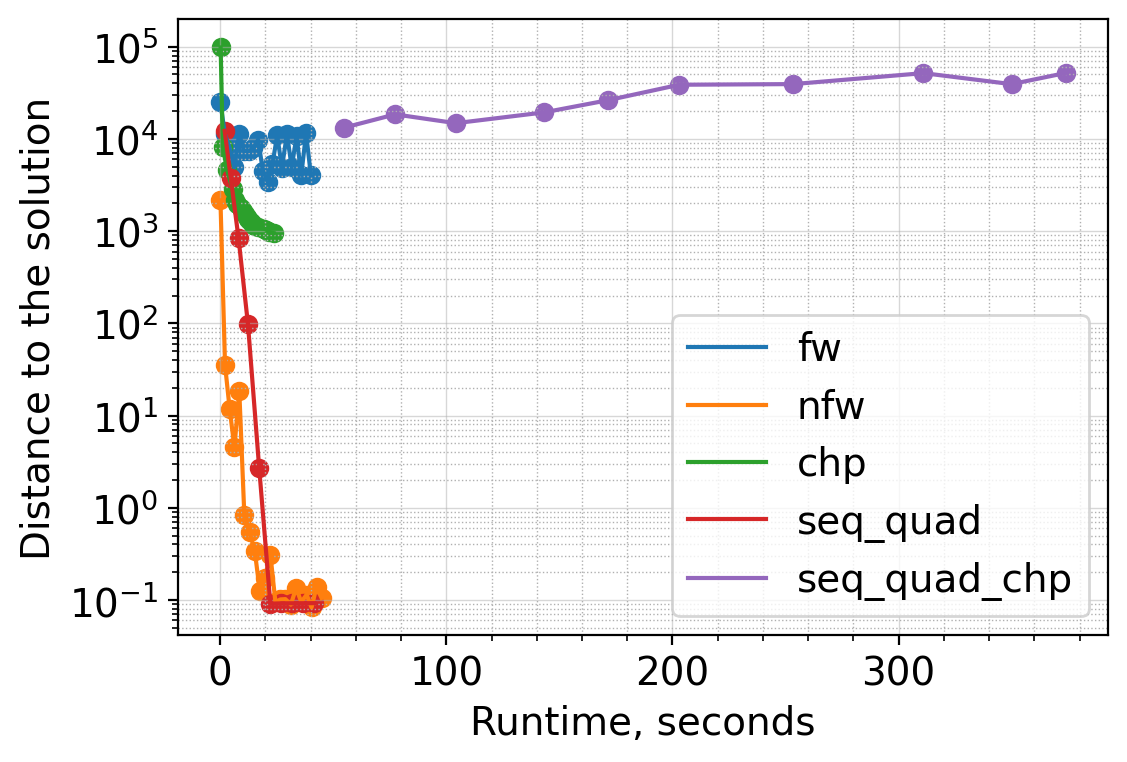

In [20]:
with open(f"experiments_data/{dirname}/{dirname}.json", "r") as fp:
    data: dict = json.load(fp)
    
plt.figure(figsize=(6,4))

true_fl = data["nfw"]["flows"]

for model_name, vals in data.items():
    time_list = vals["time_log"]
        
    if not "quad" in model_name:
        n = len(time_list) // 20
    else:
        n = 1
        
    time_log = np.array(time_list[::n])
                
    plt.plot(time_log, vals["flows_diff"][::n], label=model_name)
    plt.scatter(time_log, vals["flows_diff"][::n])

plt.minorticks_on()
plt.yscale("log")

plt.ylabel("Distance to the solution")
plt.xlabel("Runtime, seconds")

minor_locator = LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12)
plt.gca().yaxis.set_minor_locator(minor_locator)

plt.grid(which='major', linestyle='-', linewidth='0.5', alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth='0.5', alpha=1) 

plt.legend()

plt.savefig(f"experiments_data/{dirname}/{folder}_flow_dist.pdf", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

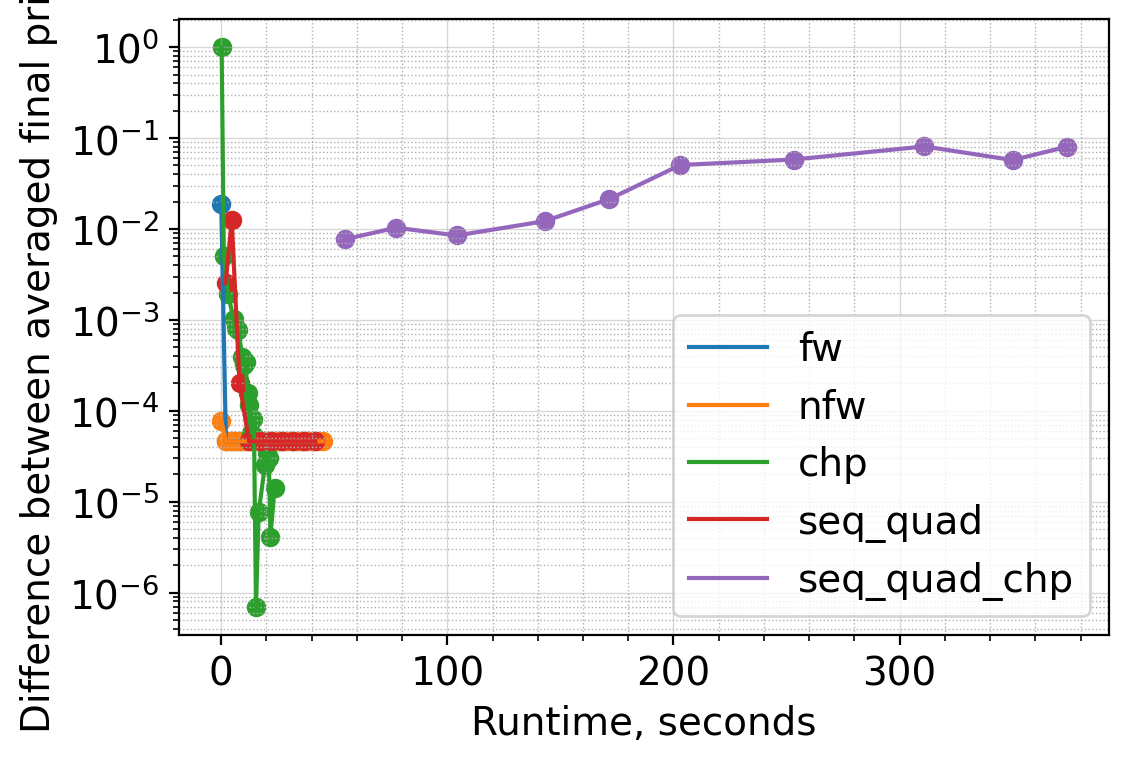

In [21]:
plt.clf()
plt.figure(figsize=(6,4))

cons_sum = data["nfw"]["primal"][-1]
for model_name, vals in data.items():
    if vals["primal"][-1] < cons_sum:
        cons_sum = vals["primal"][-1]


for model_name, vals in data.items():
    time_list = vals["time_log"]
        
    if not "quad" in model_name:
        n = len(time_list) // 20
    else:
        n = 1
        
    if model_name[:5] == "salim":
        time_log = np.array(time_list[::n]) # / 10
    else:
        time_log = np.array(time_list[::n])
        
    prime = np.abs(np.array(vals["primal"][::n]) - cons_sum) / cons_sum
    plt.plot(time_log, prime, label=model_name)
    plt.scatter(time_log, prime)

plt.minorticks_on()
# plt.ylim(bottom=np.abs(np.array(data["seq_quad"]["primal"][-1]) - cons_sum) / cons_sum + 1e-20)
plt.yscale("log")
plt.ylabel("Difference between averaged final primal")
plt.xlabel("Runtime, seconds")

minor_locator = LogLocator(base=10.0, subs=np.arange(1.0, 10.0) * 0.1, numticks=12)
plt.gca().yaxis.set_minor_locator(minor_locator)

plt.grid(which='major', linestyle='-', linewidth='0.5', alpha=0.5)
plt.grid(which='minor', linestyle=':', linewidth='0.5', alpha=1) 

plt.legend()

plt.savefig(f"experiments_data/{dirname}/{folder}_primal.pdf", bbox_inches="tight")